# Imports and Load data

This notebook present the minimum and mean inter- and intra-family distances, also the impact of different strategies on the train-to-test distance matrices relative to the full dataset.

In [2]:
from pathlib import Path
import numpy as np 
import pandas as pd

import seaborn as sns 
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
DISTANCE_PATH = Path("../data/rnadist_f_all.h5") 
SUBSAMPLED_PATH = Path("../results/ArchiveII_subsampled_ids.csv")  


families = [ "5s", "tRNA", "tmRNA", "RNaseP", "srp", "telom", "grp1", "23s", "16s"]
distances = pd.read_hdf(DISTANCE_PATH, key='rnadist')
distances /= distances.max().max()


df_ids = pd.read_csv(SUBSAMPLED_PATH)
df_ids["fam"] = df_ids["id"].str.split("_").str[0]
df_ids.loc[df_ids["fam"]=="telomerase", "fam"] = "telom"


splits = df_ids.partition.unique()
all_ids = {split: df_ids.query(f"partition == '{split}'")[["id","fam"]] for split in splits}  
ids = {}

for split in splits: 
    ids[split] = {}
    for fam in families:
        fam_ids = all_ids[split].query("fam == @fam")["id"].values
        ids[split][fam] = fam_ids

# Data processing and plotting Functions

In [4]:
def add_marginals(df):
    df_ = df.copy()
    # add marginal column ( without diagonal)
    matrix = np.zeros_like(df.values)
    matrix[np.diag_indices_from(matrix)] = np.diag(df.values)
    df_ -= matrix
    col_marginal = df_.mean(axis=1)
    # add marginal row ( without diagonal)
    row_marginal = df_.mean(axis=0)
    df["marginal"] = col_marginal
    df.loc["marginal", :] = row_marginal
    df.loc["marginal", "marginal"] = 0
    return df

def get_tables(ids, distances, families, ref_strategy="full", train_to_test=False, marginals=False):
    # Compute the mean and min distance matrices for the current strategy
    strategies = {}
    deltas = {}
    for strategy, fam_dict in ids.items():
        strategies[strategy] = {}
        deltas[strategy] = {}
        
        # Extract the relevant submatrix of distances for the current family pair
        rows = []
        for fam1, id1_list in fam_dict.items():
            if train_to_test:
                compare_fam_dict = ids[ref_strategy]
            else:
                compare_fam_dict = fam_dict 

            for fam2, id2_list in compare_fam_dict.items():

                dist_mat = distances.loc[id1_list, id2_list] 
                mean = dist_mat.values.mean()
                min = dist_mat.values.min()
                rows.append({"fam1": fam1, "fam2": fam2, "mean": mean, "min": min})
                
        # Convert the list of rows into a table with the mean / min distance matrices
        for metric in ["mean", "min"]:
            strategies[strategy][metric] = (
                pd.DataFrame(rows)
                .pivot(index="fam1", columns="fam2", values=metric)
                .reindex(index=families, columns=families) 
                .rename_axis(index=None, columns=None)
                )  
            if marginals:
                strategies[strategy][metric] = add_marginals(strategies[strategy][metric])
            if strategy == ref_strategy:
                continue
            deltas[strategy][metric] = strategies[strategy][metric] - strategies[ref_strategy][metric]
    return strategies, deltas

In [17]:
sns.set_style("white")

def plot_heatmap(df, vmin=0.1, vmax=0.65, cmap="Greens", sc = 2.15,font_size=5, save_path=None):
    plt.figure(figsize=(sc, sc), dpi=300)
    plt.rcParams.update({'font.size': font_size})
    plt.xticks(fontsize=font_size-1, rotation=45)
    plt.yticks(fontsize=font_size-1)
    sns.heatmap(df, annot=True, cmap=cmap, fmt=".2f", cbar=False,  vmin=vmin, vmax=vmax)

    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.tick_params(
        axis="x",
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False,
        labelsize=font_size,
        pad=2,
    )
    ax.set_xticklabels(df.columns, rotation=90, fontsize=font_size)
    plt.tight_layout() 
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    plt.show() 
    

In [14]:
sns.set_style("white")

# train to test plotting functions
def make_cmap(n=256): 
    mid = n // 2
    blues = plt.cm.Blues_r(np.linspace(0.05, 1.0, mid))
    reds = plt.cm.Reds(np.linspace(0.05, 1.0, n - mid))
    colors = np.vstack([blues, reds])
    colors[mid - 1:mid + 1, :] = [1, 1, 1, 1]
    return mpl.colors.ListedColormap(colors)

def style_heatmap_axis(ax, row_idx, col_idx, method, size, table, font_size):

    n_rows, n_cols = table.shape
    # Ticks at the center of each heatmap cell
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_yticks(np.arange(n_rows) + 0.5)

    # X labels: only top row
    if row_idx == 0:
        ax.xaxis.tick_top()
        ax.tick_params(
            axis="x",
            top=True,
            labeltop=True,
            bottom=False,
            labelbottom=False,
            labelsize=font_size,
            pad=2,
        )
        ax.set_xticklabels(table.columns, rotation=90, fontsize=font_size)
    else:
        ax.tick_params(axis="x", top=False, bottom=False, labeltop=False, labelbottom=False)
        ax.set_xticklabels([])

    # Y labels: only left column 
    if col_idx == 0:
        ax.tick_params(
            axis="y",
            left=True,
            labelleft=True,
            right=False,
            labelright=False,
            labelsize=font_size,
            pad=3,
        )
        ax.set_yticklabels(table.index, rotation=0, fontsize=font_size)
    else:
        ax.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
        ax.set_yticklabels([])

    # Method label: only right column
    if col_idx == 2:
        ax.text(
            1.08,
            0.5,
            method,
            transform=ax.transAxes,
            rotation=270,
            va="center",
            ha="left",
            fontsize=font_size + 2,
        )

    # Size label: only bottom row
    if row_idx == 2:
        ax.text(
            0.5,
            -0.12,
            size,
            transform=ax.transAxes,
            va="top",
            ha="center",
            fontsize=font_size + 2,
        )

    # Panel border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.2)
        spine.set_edgecolor("0.7")

def plot_delta_heatmaps(
    deltas,
    subsampled_families,
    metric="min",
    cmap=None,
    vmin=-0.1,
    vmax=0.1,
    figsize=(4.4, 2.15),
    font_size=5,
): 
    
    methods, sizes = ["randS", "sortS", "clusS"], ["400", "200", "100"]
    if cmap is None:
        cmap = make_cmap()

    plt.rcParams.update({"font.size": font_size})
    fig, axes = plt.subplots( 3, 3, figsize=figsize, dpi=300)

    for row_idx, method in enumerate(methods):
        for col_idx, size in enumerate(sizes):
            ax = axes[row_idx, col_idx]

            strategy = f"{method}{size}"
            table = deltas[strategy][metric].loc[subsampled_families, families]

            sns.heatmap(
                table,
                ax=ax,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                cbar=False,
                annot=False,
                xticklabels=False,
                yticklabels=False,
            )

            style_heatmap_axis(
                ax=ax,
                row_idx=row_idx,
                col_idx=col_idx,
                method=method,
                size=size,
                table=table,
                font_size=font_size,
            )

    fig.subplots_adjust(
        left=0.22,
        right=0.88,
        top=0.82,
        bottom=0.16,
        wspace=0.08,
        hspace=0.08,
    )

    return fig, axes

# Inter-family heatmaps

In [18]:
strategies, deltas = get_tables(ids, distances, families, ref_strategy="full", train_to_test=True, marginals=True) 

subsampled_families = ["5s", "tRNA", "tmRNA", "RNaseP", "srp", "marginal"]
cmap = make_cmap()

## Full dataset: Minimum distance

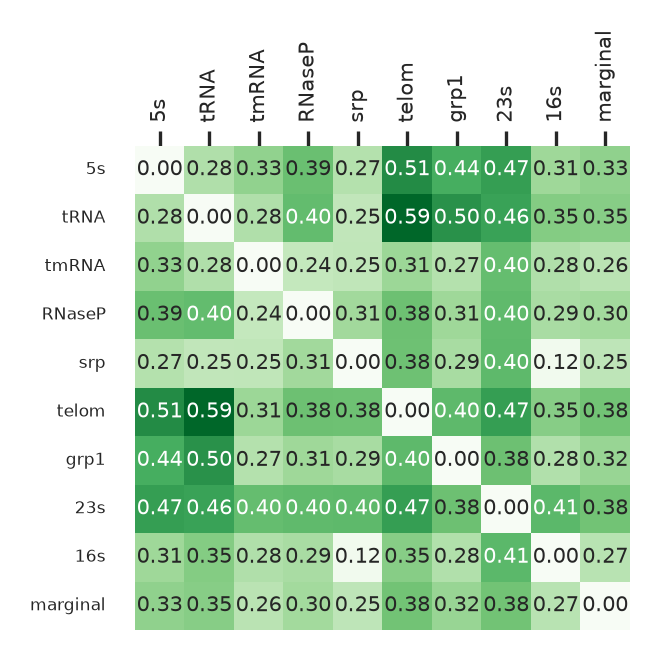

In [20]:
plot_heatmap(strategies["full"]["min"], save_path="../figures/1C_ref.svg")

## Train-to-test: minimum distances

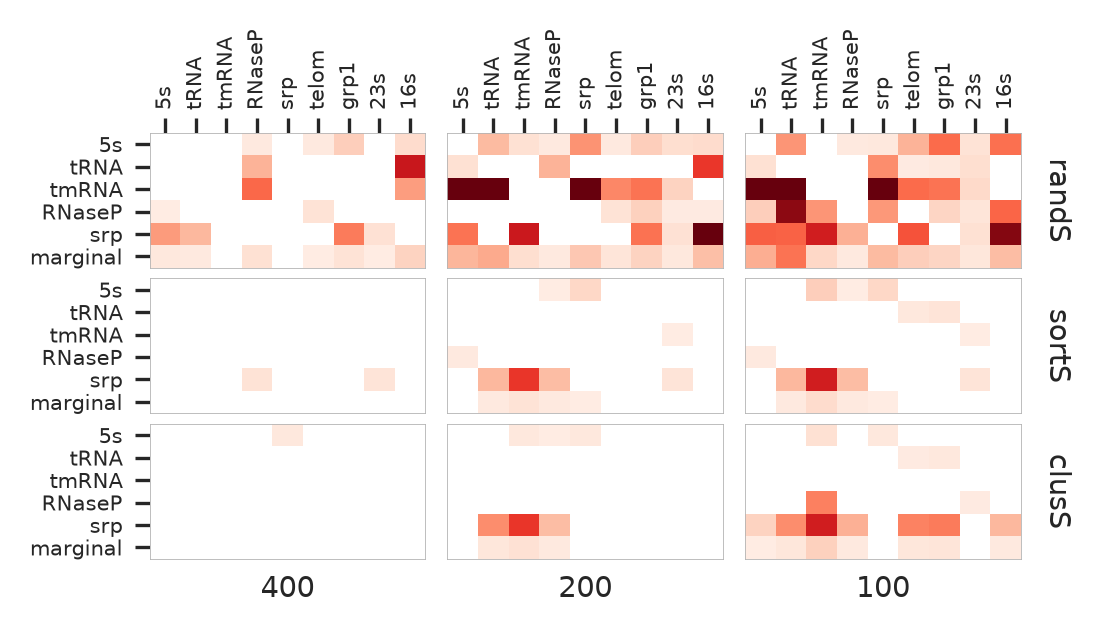

In [22]:
fig, axes = plot_delta_heatmaps(
    deltas,
    metric="min",
    subsampled_families=subsampled_families,
    cmap=cmap,
    vmin=-0.1,
    vmax=0.1,
    figsize=(4.4, 2.15),
    font_size=5,
)
plt.savefig("../figures/1C_delta.svg", dpi=300)
plt.show()

## Full dataset: Mean distance

Full strategy - Mean Distances


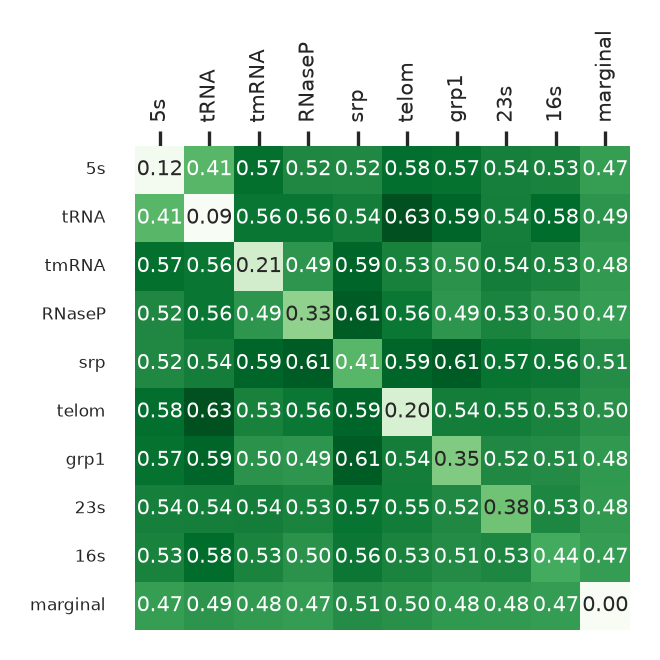

In [23]:
print("Full strategy - Mean Distances") 
plot_heatmap(strategies["full"]["mean"], save_path="../figures/1D_ref.svg")

## Train-to-test: mean distances

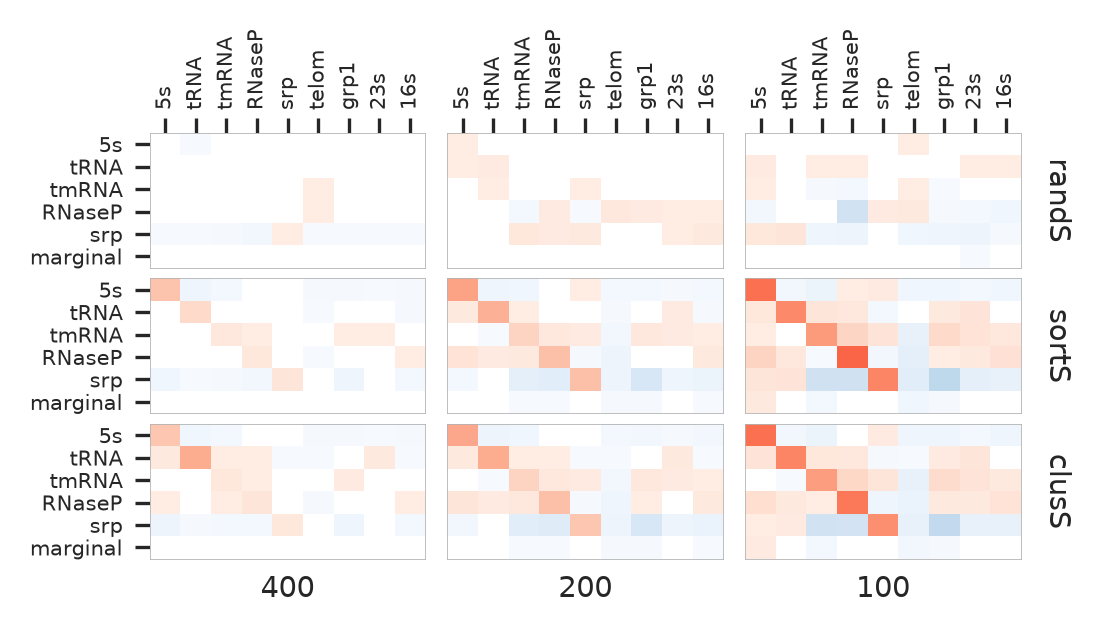

In [24]:
fig, axes = plot_delta_heatmaps(
    deltas,
    metric="mean",
    subsampled_families=subsampled_families,
    cmap=cmap,
    vmin=-0.1,
    vmax=0.1,
    figsize=( 4.4, 2.15),
    font_size=5
)
plt.savefig("../figures/1D_delta.svg", dpi=300)
plt.show()